In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from feature_eng_exports import data

There are 17032 rows and 16 columns in the dataset.
There are 2924 duplicated rows.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17032 entries, 0 to 17031
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   model            17032 non-null  object
 1   price            17032 non-null  object
 2   price_score      16732 non-null  object
 3   plate            17032 non-null  object
 4   Reg. year        17032 non-null  object
 5   Fuel             17032 non-null  object
 6   KM driven        17032 non-null  object
 7   Transmission     17032 non-null  object
 8   Engine capacity  16716 non-null  object
 9   Ownership        17032 non-null  object
 10  Make year        17032 non-null  object
 11  Spare key        9886 non-null   object
 12  Reg number       9886 non-null   object
 13  Insurance        4521 non-null   object
 14  Insurance type   11667 non-null  object
 15  Source           17032 non-null  obje

c:\Users\sisfi\OneDrive\Desktop\DataA\smart-buy-classifier\notebooks\data_clean_exports.py:73: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Ownership'] = data['Ownership'].replace(maps)
c:\Users\sisfi\OneDrive\Desktop\DataA\smart-buy-classifier\notebooks\data_clean_exports.py:182: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Reg. year'] = pd.to_datetime(data['Reg. year']).dt.year
c:\Users\sisfi\OneDrive\Desktop\DataA\smart-buy-classifier\notebooks\data_clean_exports.py:183: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is cons

After dropping duplicates, 13970 rows remain.
<class 'pandas.core.frame.DataFrame'>
Index: 13970 entries, 0 to 17031
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   model            13970 non-null  object 
 1   price            13970 non-null  float64
 2   price_score      7099 non-null   object 
 3   plate            13970 non-null  object 
 4   Reg. year        13970 non-null  int32  
 5   Fuel             13970 non-null  object 
 6   KM driven        13970 non-null  int64  
 7   Transmission     13970 non-null  object 
 8   Engine capacity  13970 non-null  Float64
 9   Ownership        13970 non-null  int64  
 10  Make year        13970 non-null  int32  
 11  Insurance type   13970 non-null  object 
 12  Source           13970 non-null  object 
 13  variant          13970 non-null  object 
 14  car_age          13970 non-null  int32  
 15  reg_age          13970 non-null  int32  
 16  ngt_life         

In [2]:
# sklearn imports
from sklearn.model_selection import KFold, cross_val_score, train_test_split

# Preparing Data

In [3]:
xg_X = data[[
    'model',
    'Fuel',
    'Transmission',
    'KM driven',
    'Engine capacity',
    'Ownership',
    'car_age',
    'ngt_life',
    'ngt_critical',
    're_register',
    # 'km_per_year',
    'is_luxury_brand',
    # 'ownership_strength',
    'frequency',
]].copy()


In [4]:
# Converting Fuel and Transmission to explicitly categorical dtypes :
xg_X['model'] = xg_X['model'].astype('category')
xg_X['Fuel'] = xg_X['Fuel'].astype('category')
xg_X['Transmission'] = xg_X['Transmission'].astype('category')

In [5]:
# Creating Y
xg_Y = pd.Series(np.log1p(data['price']))

# Cross-validation of Initial XGBoost Model

In [6]:
# Initialising initial regressor parameters
bt = xgb.XGBRegressor(
    eta = 0.05,
    min_child_weight = 10,
    subsample = 0.8,
    max_depth = 6,
    enable_categorical=True, 
    random_state = 420
)

In [7]:
# Evaluating cross validation score
xgb_kf = KFold(n_splits=10, shuffle=True, random_state=40)
cross_val_score(bt, xg_X, xg_Y, cv=xgb_kf)

array([0.94226515, 0.96561004, 0.96520563, 0.96074805, 0.96213759,
       0.96055297, 0.96190476, 0.96241408, 0.95701353, 0.95513211])

# Optuna Tuning of XGBoost Model

In [8]:
X_train, X_test, y_train, y_test = train_test_split(xg_X, xg_Y, test_size=0.2)

In [11]:
def objective(trial):

    param = {
        'eta': trial.suggest_float('eta', 0, 1),
        'lambda': trial.suggest_float('lambda',0,20),
        "alpha": trial.suggest_float("alpha", 1e-8, 1.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.2, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight",2,50),
        "max_depth": trial.suggest_int("max_depth",3,15)

    }
    
    opt_kf = KFold(n_splits=3, shuffle=True, random_state=40)

    optuna_xgb = xgb.XGBRegressor(**param, device = 'cuda')
    opt_score = cross_val_score(optuna_xgb,X_train, y_train, cv=opt_kf).mean()
    
    return opt_score

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

[I 2026-06-27 02:42:05,289] A new study created in memory with name: no-name-54d7421f-f366-42bc-a283-e49aaef700ee


  0%|          | 0/150 [00:00<?, ?it/s]

c:\Users\sisfi\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:553: UserWarning: [02:42:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[I 2026-06-27 02:42:09,075] Trial 0 finished with value: 0.94467981646075 and parameters: {'eta': 0.34493367250754725, 'lambda': 7.219651766508441, 'alpha': 1.2261659261847856e-05, 'subsample': 0.3168558465373863, 'colsample_bytree': 0.3824299495770885, 'min_child_weight': 47, 'max_depth': 15}. Best is trial 0 with value: 0.94467981646075.
[I 2026-06-27 02:42:11,403] Trial 1 finished with value: 0.9383057728984728 and parameters: {'eta': 0.8837831345614914, 'lambda': 15.116395867950278, 'alpha': 0.5551039921491246, 'subsample': 0.33291264198490755, 'colsample_bytree': 0.41795027531388984, 'min_child_weight': 43, 'max_depth': 13}. Best is trial 0 with value: 0.94467981646075.
[I 2026-06-27 02:42:12,244] Trial 2 finished with value: 0.9363898513715526 and parameters: {'eta': 0.997565248084338, 'lambda': 2.5010987244125493, 'alpha': 0.015598751939722495, 'subsample': 0.5288804776979348, 'colsample_bytree': 0.826447398448892, 'min_child_weight': 3, 'max_depth': 3}. Best is trial 0 with val

In [ ]:
# Storing best parameters :
best_pars = study.best_params
xgb_fin = xgb.XGBRegressor(**best_pars, random_state= 40)
xgb_fin.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7261614701046673
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [19]:
print(f"BEST PARAMETERS: {best_pars}")

BEST PARAMETERS: {'eta': 0.12850007205781155, 'lambda': 3.142671812541689, 'alpha': 0.005581609835210409, 'subsample': 0.9309223077609553, 'colsample_bytree': 0.7261614701046673, 'min_child_weight': 5, 'max_depth': 6}


In [20]:
# Final cross validation scores :
cross_val_score(xgb_fin,X_train, y_train, cv=xgb_kf)

array([0.95723824, 0.96044372, 0.95805113, 0.96246445, 0.95993347,
       0.96378537, 0.95982772, 0.95993826, 0.95921922, 0.95389944])

In [16]:
# Visualising feature importance :
import optuna.visualization as vis
vis.plot_param_importances(study=study)

In [17]:
vis.plot_optimization_history(study=study)

# SHAP Explainability

In [24]:
import shap

explainer_xgb = shap.TreeExplainer(xgb_fin)
shap_vals = explainer_xgb(X_test)

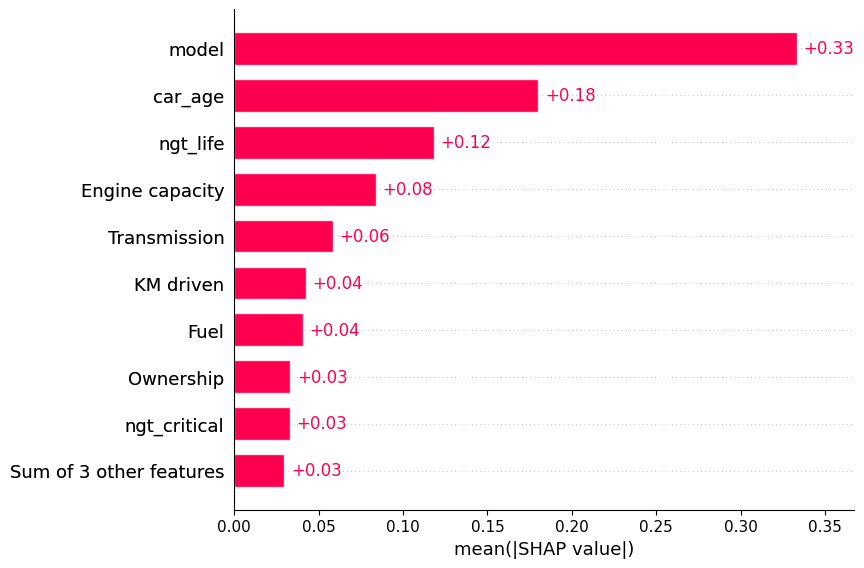

In [25]:
shap.plots.bar(shap_vals)

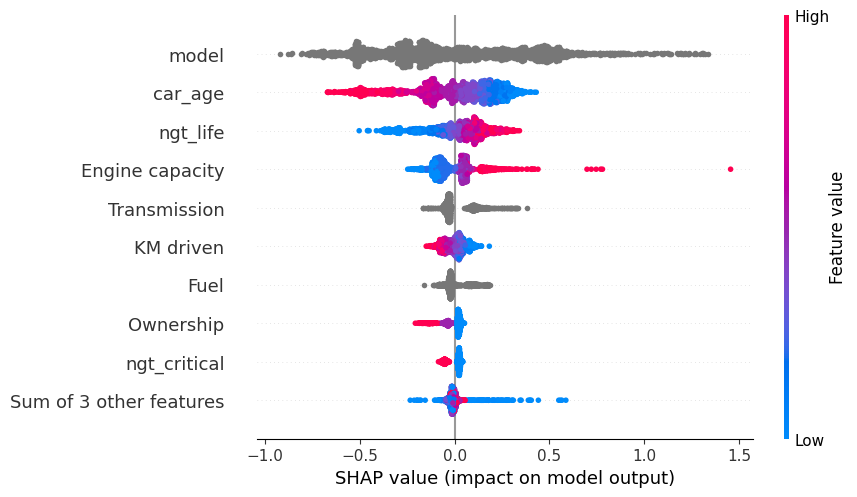

In [26]:
shap.plots.beeswarm(shap_vals)